
# End-to-End Credit Risk & Loan Default Analytics Project

## Project Overview
This project builds a comprehensive, production-grade analytics pipeline for a financial institution's retail lending portfolio. It transitions across all stages of the data maturity model—moving from raw data collection to deep diagnostic statistics, predictive machine learning modeling, prescriptive decision logic, and executive-level reporting.

The core business objective is to minimize portfolio **Non-Performing Loans (NPLs)** and optimize interest revenue by accurately estimating an applicant's **Probability of Default (PD)** and dynamically adjusting lending strategy thresholds.

## Project Architecture & Analytics Framework

The project is structured into five sequential phases:


[1. Data Collection] ➔ [2. Diagnostics & EDA] ➔ [3. Predictive Modeling] ➔ [4. Prescriptive Strategy] ➔ [5. Reporting]

### 1. Data Collection & Engineering
* **Data Sourcing:** Historical retail banking credit risk portfolio data stored natively in local environment (`data/credit_risk_dataset.csv`).
* **Schema Auditing:** Assessing structural columns including borrower demographics (age, income, home ownership), loan details (amount, grade, interest rate), and credit bureau historical risk flags.
* **Tech Stack:** Python, Pandas.

### 2. Diagnostic Analytics (The "Why")
Before predicting future outcomes, we mathematically diagnose historical structural relationships:
* **Data Sanitization:** Treating missing values (`loan_int_rate`, `person_emp_length`) and isolating extreme biological/financial outliers (e.g., recorded ages $> 100$).
* **Statistical Hypothesis Testing:** Executing Chi-Square Tests of Independence and Two-Sample $t$-tests to confirm if defaults structurally differ across variables like employment categories or loan purposes.
* **Customer Segmentation:** Utilizing behavioral metrics to segment borrowers into clear risk cohorts (e.g., low-risk vs. high-volatility profiles).

### 3. Predictive Modeling (The "What Will Happen?")
Building a supervised machine learning engine to quantify the exact risk profile of incoming credit applicants:
* **Feature Engineering:** Crafting advanced predictive features such as *Debt-to-Income Ratio*, *Installment-to-Income Ratios*, and risk-adjusted pricing weights.
* **Model Selection:** Implementing and tuning robust algorithms including **Logistic Regression** (for financial interpretability) and **XGBoost/Random Forest** (for non-linear risk captures).
* **Performance Optimization:** Validating systems using stratified cross-validation, ROC-AUC, Precision-Recall curves, and probability calibration scores.

### 4. Prescriptive Analytics (The "What Should We Do?")
Translating raw predictive probabilities ($PD$) into automated corporate strategy:
* **Optimization Thresholding:** Calculating the mathematical cutoff score where marginal profit balances marginal risk.
* **Risk-Based Pricing Engine:** Engineering a rule-based prescriptive algorithm that dynamically optimizes loan amounts, durations, and interest premiums based on the applicant's risk tier instead of issuing a blind rejection.

### 5. Interactive Reporting & Insights Delivery
* **Bi-Dashboard Construction:** Designing an executive-level tracking interface using Power BI.
* **Core Metrics Tracked:** Non-Performing Loan (NPL) Rate, Total Portfolio-at-Risk (PAR), Expected Loss ($EL$), and a live interactive scenario matrix allowing risk officers to adjust credit cutoff sliders to simulate projected revenue impacts.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os 
df = pd.read_csv(r"C:\Users\HP\Desktop\SKILL LAB\EXCEL\credit_risk_dataset.csv")
df.head()




,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
#---missing values and abnomality audit---
print("--missing values---")
print(df.isnull().sum()[df.isnull().sum()>0])
print("--abnormal values---")

#---Numerical data abnormality audit---
print(df[["person_age","person_income","person_emp_length","loan_amnt"]].describe())

--missing values---
person_emp_length     895
loan_int_rate        3116
dtype: int64
--abnormal values---
         person_age  person_income  person_emp_length     loan_amnt
count  32581.000000   3.258100e+04       31686.000000  32581.000000
mean      27.734600   6.607485e+04           4.789686   9589.371106
std        6.348078   6.198312e+04           4.142630   6322.086646
min       20.000000   4.000000e+03           0.000000    500.000000
25%       23.000000   3.850000e+04           2.000000   5000.000000
50%       26.000000   5.500000e+04           4.000000   8000.000000
75%       30.000000   7.920000e+04           7.000000  12200.000000
max      144.000000   6.000000e+06         123.000000  35000.000000


In [3]:
# 1. Identify the specific indices of the extreme anomalies we saw in step 1
age_outliers = df[df['person_age'] > 90].index
emp_outliers = df[df['person_emp_length'] > df['person_age']].index

# 2. Combine them into a single list of rows to drop
all_outliers_to_drop = age_outliers.union(emp_outliers)

# 3. Create the clean dataframe by dropping those exact rows
clean_df = df.drop(index=all_outliers_to_drop).copy()

# 4. Print the correct breakdown using the right variables
print(f"Original dataset rows : {df.shape[0]}")
print(f"Cleaned dataset rows  : {clean_df.shape[0]}")
print(f"Anomalous rows removed: {df.shape[0] - clean_df.shape[0]}")

Original dataset rows : 32581
Cleaned dataset rows  : 32573
Anomalous rows removed: 8


#Null handling

In [4]:
#--null values imputation---
# 1. Calculate the median employment length from our clean dataframe
emp_median = clean_df['person_emp_length'].median()
print(f" Portfolio Median Employment Length: {emp_median} years")

# 2. Impute (fill) the missing values in that column
clean_df['person_emp_length'] = clean_df['person_emp_length'].fillna(emp_median)

# 3. Verify that employment length now has 0 missing values
print(f"Missing values left in employment length: {clean_df['person_emp_length'].isnull().sum()}")
# 1. Fill missing interest rates based on the median of their specific Loan Grade
clean_df['loan_int_rate'] = clean_df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

# 2. Final check to ensure absolutely zero missing values remain in the entire dataset
print("--- Final Missing Values Audit ---")
print(clean_df.isnull().sum())

 Portfolio Median Employment Length: 4.0 years
Missing values left in employment length: 0
--- Final Missing Values Audit ---
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [5]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


#Diagnostic Deep-Dive (Analyzing the "Why")

 Baseline Portfolio Default Rate: 21.82%


C:\Users\HP\AppData\Local\Temp\ipykernel_9816\2956686929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


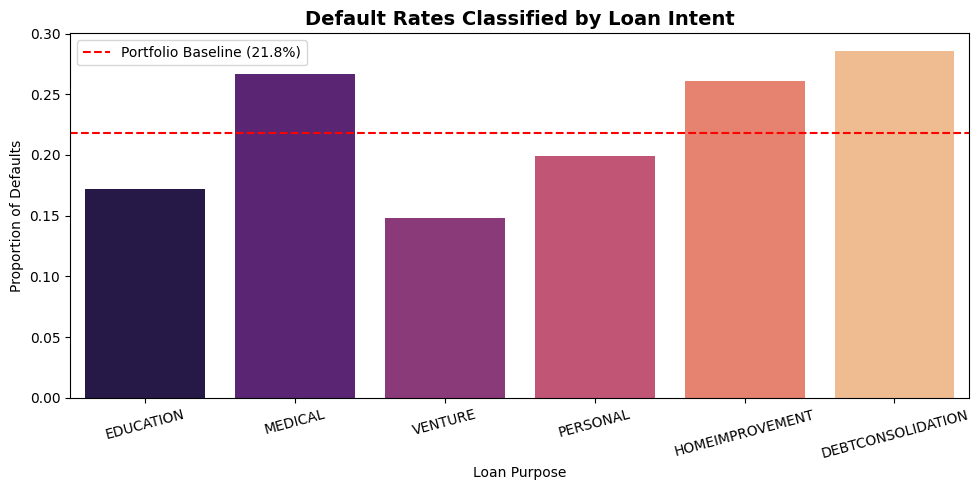

In [6]:


# 1. Calculate overall portfolio default rate (NPL Rate)
npl_rate = clean_df['loan_status'].mean()
print(f" Baseline Portfolio Default Rate: {npl_rate * 100:.2f}%")

# 2. Financial Diagnosis: How does risk scale by loan purpose?
plt.figure(figsize=(10, 5))
sns.barplot(
    data=clean_df, 
    x='loan_intent', 
    y='loan_status', 
    estimator=np.mean, 
    errorbar=None, 
    palette="magma"
)

# Read a red reference line for the baseline default rate
plt.axhline(npl_rate, color='red', linestyle='--', label=f'Portfolio Baseline ({npl_rate*100:.1f}%)')

plt.title('Default Rates Classified by Loan Intent', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Defaults')
plt.xlabel('Loan Purpose')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#Statistical Diagnostics

In [7]:
from scipy.stats import chi2_contingency

# 1. Create a cross-tabulation table (contingency table) between intent and status
contingency_table = pd.crosstab(clean_df['loan_intent'], clean_df['loan_status'])
print("--- Contingency Table (Actual Counts) ---")
print(contingency_table)

# 2. Run the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n--- Statistical Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p}")

# 3. Interpret the result
alpha = 0.05
if p < alpha:
    print("\n Decision: Reject Null Hypothesis (H0).")
    print("Statistical Proof: Loan intent is significantly associated with default risk.")
else:
    print("\n Decision: Fail to Reject Null Hypothesis (H0).")
    print("Statistical Proof: No significant association found.")


--- Contingency Table (Actual Counts) ---
loan_status           0     1
loan_intent                  
DEBTCONSOLIDATION  3722  1490
EDUCATION          5340  1111
HOMEIMPROVEMENT    2664   941
MEDICAL            4449  1621
PERSONAL           4422  1097
VENTURE            4869   847

--- Statistical Test Results ---
Chi-Square Statistic: 520.0818
p-value: 3.690600218974067e-110

 Decision: Reject Null Hypothesis (H0).
Statistical Proof: Loan intent is significantly associated with default risk.


#Diagnosing Numerical Features (Borrower Income)

In [8]:
#Diagnosing Numerical Features (Borrower Income)
from scipy.stats import ttest_ind

# 1. Group by loan status and look at the income distributions
income_stats = clean_df.groupby('loan_status')['person_income'].agg(['count', 'mean', 'median'])
print("--- Income Distribution Split by Loan Status ---")
print(income_stats)

# 2. Separate the income groups for the statistical test
income_good_standing = clean_df[clean_df['loan_status'] == 0]['person_income']
income_defaulted = clean_df[clean_df['loan_status'] == 1]['person_income']

# 3. Run a Two-Sample t-test (assuming unequal variance)
t_stat, p_val = ttest_ind(income_good_standing, income_defaulted, equal_var=False)

print("\n--- Numerical T-Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"p-value: {p_val}")

# 4. Decision logic
if p_val < 0.05:
    print("\n Decision: Reject Null Hypothesis (H0).")
    print("Statistical Proof: There is a significant difference in income between customers who default and those who don't.")
else:
    print("\n Decision: Fail to Reject Null Hypothesis (H0).")
    print("Statistical Proof: Income differences are not statistically significant.")

--- Income Distribution Split by Loan Status ---
             count          mean   median
loan_status                              
0            25466  70555.858714  60000.0
1             7107  49124.262839  41496.0

--- Numerical T-Test Results ---
T-Statistic: 38.4035
p-value: 1.90305868197909e-309

 Decision: Reject Null Hypothesis (H0).
Statistical Proof: There is a significant difference in income between customers who default and those who don't.


#3 PREDICTIVE MODELING

In [9]:
# 1. Identify categorical columns that need encoding
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# 2. Apply One-Hot Encoding (converts text columns into 0 and 1 columns)
encoded_df = pd.get_dummies(clean_df, columns=categorical_cols, drop_first=True)

# 3. Separate our Features (X) from our Target Variable (y)
X = encoded_df.drop(columns=['loan_status'])
y = encoded_df['loan_status']

print("--- Data Restructuring Complete ---")
print(f"Features dataset (X) shape: {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target variable (y) shape : {y.shape[0]} rows")

--- Data Restructuring Complete ---
Features dataset (X) shape: 32573 rows, 22 columns
Target variable (y) shape : 32573 rows


#Next Step: Splitting Data into Training & Testing Sets

In [10]:
from sklearn.model_selection import train_test_split

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("--- Train-Test Split Completed ---")
print(f" Training set features size (X_train): {X_train.shape}")
print(f"Testing set features size (X_test)  : {X_test.shape}")
print(f"Baseline Default Distribution in Training Set:\n{y_train.value_counts(normalize=True)}")

--- Train-Test Split Completed ---
 Training set features size (X_train): (26058, 22)
Testing set features size (X_test)  : (6515, 22)
Baseline Default Distribution in Training Set:
loan_status
0    0.781794
1    0.218206
Name: proportion, dtype: float64


#Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Identify continuous numerical columns that need scaling (excluding encoded 0/1 dummies)
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'loan_percent_income']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Create a copy of the splits to store scaled versions
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. Fit on the training set and transform BOTH training and testing sets
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("--- Feature Scaling Complete ---")
print("Preview of scaled training features:")
print(X_train_scaled[numerical_cols].head(3))

--- Feature Scaling Complete ---
Preview of scaled training features:
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
24403    0.374838       0.121009           2.075055   0.384627      -0.978331   
31583    2.319240       0.858269           0.314013   0.194210       1.009044   
14141   -0.759396       0.664253           0.565591   0.860669       1.547097   

       cb_person_cred_hist_length  loan_percent_income  
24403                    0.549968            -0.004239  
31583                    2.780329            -0.658878  
14141                   -0.936940            -0.191278  


#Training My 1st dataset


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the model 
# We add class_weight='balanced' to handle the fact that we have more non-defaults than defaults
log_reg = LogisticRegression(random_state=42, class_weight='balanced')

# 2. Fit (train) the model on our scaled training datasets
print("Training the Logistic Regression model...")
log_reg.fit(X_train_scaled, y_train)
print("Training complete!\n")

# 3. Make predictions on our scaled test data
y_pred = log_reg.predict(X_test_scaled)

# 4. Generate the performance metrics report
print("--- Evaluation Metrics ---")
print(classification_report(y_test, y_pred))

Training the Logistic Regression model...
Training complete!

--- Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      5094
           1       0.54      0.76      0.63      1421

    accuracy                           0.81      6515
   macro avg       0.73      0.79      0.75      6515
weighted avg       0.84      0.81      0.82      6515



#Visualizing the Results: The Confusion Matrix

<Figure size 600x500 with 0 Axes>

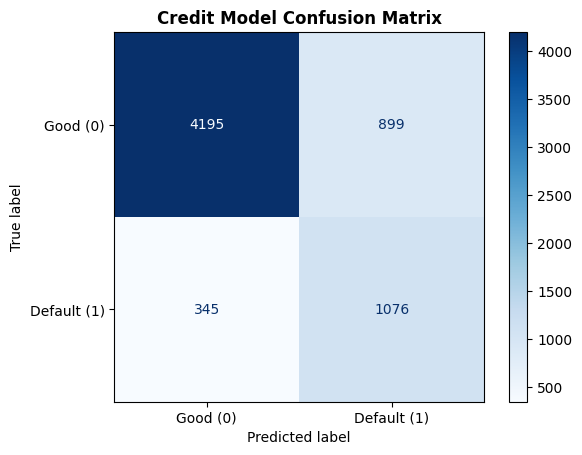

In [13]:
#visualizing the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# 2. Display the matrix using a clean professional color map
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Default (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Credit Model Confusion Matrix', fontsize=12, fontweight='bold')
plt.grid(False) # Turn off gridlines for clean visual presentation
plt.show()


#PRESCRIPTIVE ANALYTICS

In [14]:
# 1. Extract the raw predicted probabilities for the positive class (Default)
# .predict_proba() returns [probability of 0, probability of 1]
y_probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Create a clean strategy dataframe combining the true values and their calculated risk probabilities
strategy_df = pd.DataFrame({
    'Actual_Status': y_test.values,
    'Default_Probability': y_probabilities
})

# 3. View a preview of our new risk scoring engine
print("--- Risk Scoring Engine Preview ---")
print(strategy_df.head(10))

# 4. Descriptive check on our probability ranges
print("\n--- Probability Spread Summary ---")
print(strategy_df['Default_Probability'].describe())

--- Risk Scoring Engine Preview ---
   Actual_Status  Default_Probability
0              0             0.197913
1              0             0.975155
2              0             0.286476
3              1             0.976799
4              0             0.083744
5              0             0.319978
6              0             0.089454
7              0             0.091552
8              0             0.116205
9              0             0.013917

--- Probability Spread Summary ---
count    6515.000000
mean        0.374415
std         0.293596
min         0.001078
25%         0.127529
50%         0.278073
75%         0.592344
max         0.999797
Name: Default_Probability, dtype: float64


#Building the Prescriptive Strategy Engine

In [15]:
# 1. Define a function to prescribe business strategies based on probability tiers
def prescribe_credit_strategy(prob):
    if prob <= 0.25:
        return 'Green Tier (Standard Approval)'
    elif prob <= 0.60:
        return 'Amber Tier (Risk-Adjusted Conditional Approval)'
    else:
        return 'Red Tier (Automatic Decline)'

# 2. Apply the strategy function to our scoring table
strategy_df['Prescribed_Strategy'] = strategy_df['Default_Probability'].apply(prescribe_credit_strategy)

# 3. Analyze the volume distribution across our strategic tiers
print("---  Prescribed Credit Portfolio Breakdown ---")
tier_counts = strategy_df['Prescribed_Strategy'].value_counts()
tier_proportions = strategy_df['Prescribed_Strategy'].value_counts(normalize=True) * 100

for tier in tier_counts.index:
    print(f"{tier}: {tier_counts[tier]} customers ({tier_proportions[tier]:.2f}%)")
       


---  Prescribed Credit Portfolio Breakdown ---
Green Tier (Standard Approval): 3016 customers (46.29%)
Amber Tier (Risk-Adjusted Conditional Approval): 1900 customers (29.16%)
Red Tier (Automatic Decline): 1599 customers (24.54%)


C:\Users\HP\AppData\Local\Temp\ipykernel_9816\2302551317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_9816\2302551317.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Green Tier\n(Approve)', 'Amber Tier\n(Conditional)', 'Red Tier\n(Decline)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_9816\2302551317.py:54: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\Desktop\Analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


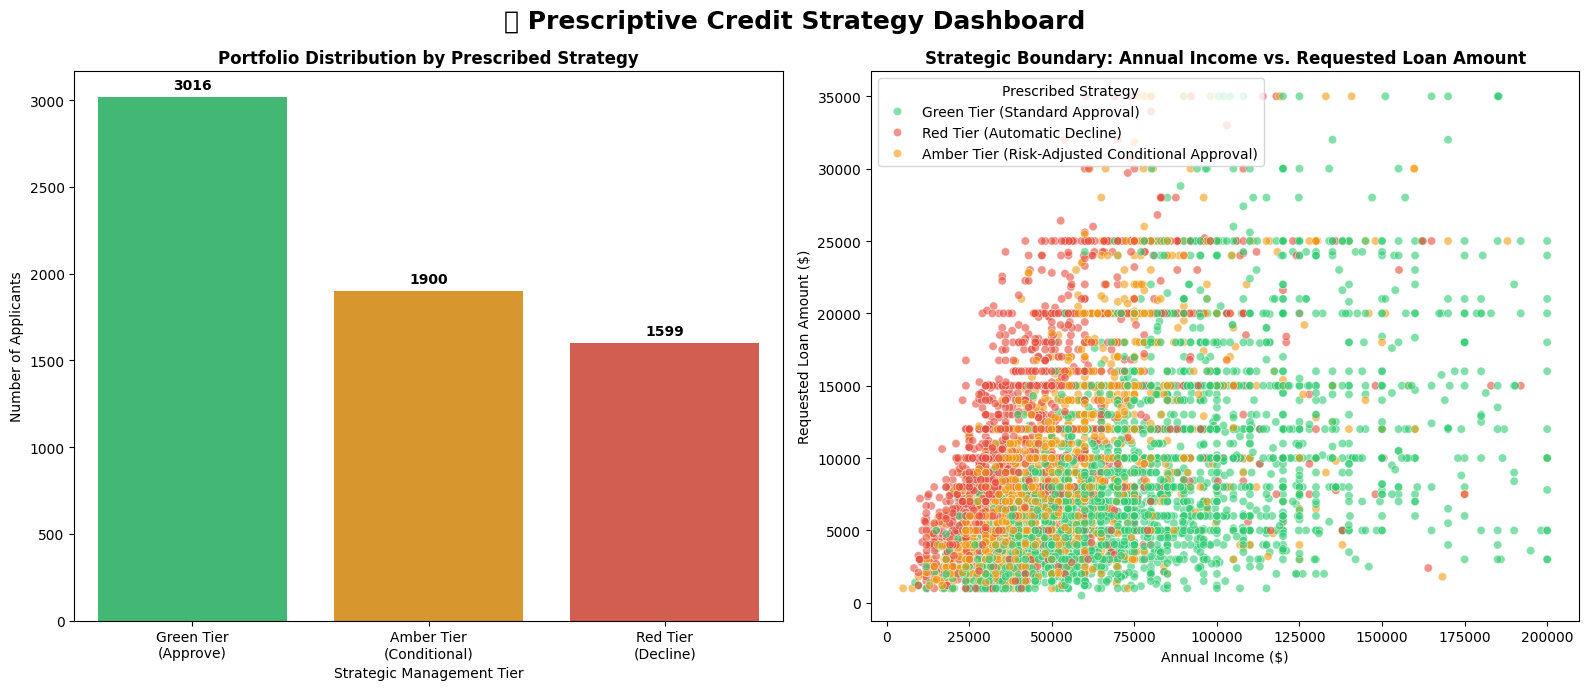

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our professional credit color palette
strategy_palette = {
    'Green Tier (Standard Approval)': '#2ecc71',      # Emerald Green
    'Amber Tier (Risk-Adjusted Conditional Approval)': '#f39c12',  # Warning Orange
    'Red Tier (Automatic Decline)': '#e74c3c'         # Risk Red
}

# 2. Set up a dual-panel dashboard figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('💳 Prescriptive Credit Strategy Dashboard', fontsize=18, fontweight='bold', y=0.98)

# --- PANEL 1: Portfolio Tier Counts (Bar Chart) ---
sns.countplot(
    data=strategy_df, 
    x='Prescribed_Strategy', 
    ax=axes[0], 
    palette=strategy_palette,
    order=strategy_palette.keys()
)
axes[0].set_title('Portfolio Distribution by Prescribed Strategy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Strategic Management Tier')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_xticklabels(['Green Tier\n(Approve)', 'Amber Tier\n(Conditional)', 'Red Tier\n(Decline)'])

# Add value annotations on top of the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 30),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')


# --- PANEL 2: Strategic Financial Mapping (Scatter Plot) ---
# We limit x-axis to 200k to maintain clear visibility of the bulk core portfolio
plot_df = X_test.copy()
plot_df['Prescribed_Strategy'] = strategy_df['Prescribed_Strategy'].to_numpy()

sns.scatterplot(
    data=plot_df[plot_df['person_income'] <= 200000],
    x='person_income',
    y='loan_amnt',
    hue='Prescribed_Strategy',
    palette=strategy_palette,
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Strategic Boundary: Annual Income vs. Requested Loan Amount', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Requested Loan Amount ($)')
axes[1].legend(title="Prescribed Strategy", loc='upper left')

# Final formatting adjustments
plt.tight_layout()
plt.show()

#Final Phase: Reporting & Exporting for Dashboarding

In [17]:
# 1. Align the original unscaled test details with our computed probabilities
reporting_df = X_test.copy()
reporting_df['Actual_Status'] = y_test.values
reporting_df['Default_Probability'] = strategy_df['Default_Probability'].values
reporting_df['Prescribed_Strategy'] = strategy_df['Prescribed_Strategy'].values

# 2. Save the final model outputs as a CSV for dashboard consumption
output_filename = "credit_risk_model_outputs.csv"
reporting_df.to_csv(output_filename, index=False)

print("---  Portfolio Output Pipeline Complete ---")
print(f"Success! Generated reporting asset file: '{output_filename}'")
print(f"Dimensions exported: {reporting_df.shape[0]} rows ready for Power BI layout.")


---  Portfolio Output Pipeline Complete ---
Success! Generated reporting asset file: 'credit_risk_model_outputs.csv'
Dimensions exported: 6515 rows ready for Power BI layout.
